In [1210]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install rdkit
!pip install xgboost lightgbm catboost
!pip install tqdm

In [1211]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [1212]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1213]:
file1_path = "/content/drive/My Drive/train.csv"
train = pd.read_csv(file1_path)
train.head()


,c_id,a_id,T,P,x_co2
0,C0011,A0046,303.15,7.0,0.159
1,C0011,A0046,313.15,9.7,0.159
2,C0011,A0046,323.15,12.6,0.159
3,C0011,A0046,333.15,16.4,0.159
4,C0011,A0046,343.15,21.2,0.159


In [1214]:
file2_path = "/content/drive/My Drive/test.csv"
test = pd.read_csv(file2_path)
test.head()

,Id,c_id,a_id,T,P
0,1,C0072,A0074,313.20,1.00
1,2,C0046,A0039,298.15,2.96
2,3,C0046,A0039,298.15,3.47
3,4,C0046,A0039,298.15,4.08
4,5,C0046,A0039,298.15,4.70


In [1215]:
file3_path = "/content/drive/My Drive/SMILES.xlsx"
smiles_df = pd.read_excel(file3_path)
smiles_df.head()


,c_a_ID,SMILES
0,A0001,O=C(C)[O-]
1,A0002,CC1=CC(=O)[N-]S(=O)(=O)O1
2,A0003,C(N)(C)(C(=O)[O-])
3,A0005,C(F)(F)(F)C(F)(F)S(=O)(=O)[N-]S(=O)(=O)C(F)(F)...
4,A0006,[B-](F)(F)(F)(F)


In [1216]:
unique_ids = pd.concat([train[['c_id']], train[['a_id']],test[['c_id']], test[['a_id']]], ignore_index=True).stack().unique()
filtered_smiles = smiles_df[smiles_df['c_a_ID'].isin(unique_ids)]

In [1217]:
from rdkit import Chem
from rdkit.Chem import Descriptors
import pandas as pd
from tqdm import tqdm

tqdm.pandas()  # for progress bars

# Descriptor list (excluding FormalCharge, we handle it separately)
descriptor_list = [
    ('MolWt', Descriptors.MolWt),
    ('TPSA', Descriptors.TPSA),
    ('NumRotatableBonds', Descriptors.NumRotatableBonds),
    ('NumHAcceptors', Descriptors.NumHAcceptors),
    ('NumHDonors', Descriptors.NumHDonors),
    ('MolLogP', Descriptors.MolLogP),
    ('RingCount', Descriptors.RingCount),
    ('NumHeavyAtoms', Descriptors.HeavyAtomCount),
]

# Add 'FormalCharge' manually at the end
descriptor_names = [name for name, _ in descriptor_list] + ['FormalCharge']

# Function to compute all descriptors including FormalCharge
def compute_rdkit_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return [None] * len(descriptor_names)

    desc_values = [desc(mol) for _, desc in descriptor_list]
    formal_charge = sum(atom.GetFormalCharge() for atom in mol.GetAtoms())
    desc_values.append(formal_charge)
    return desc_values

# Assuming your DataFrame is called `smiles_df` and has: c_a_Id, SMILES
smiles_df[descriptor_names] = smiles_df['SMILES'].progress_apply(
    lambda smi: pd.Series(compute_rdkit_descriptors(smi))
)


100%|██████████| 133/133 [00:00<00:00, 494.43it/s]


In [1218]:
smiles_df.head()

,c_a_ID,SMILES,MolWt,TPSA,NumRotatableBonds,NumHAcceptors,NumHDonors,MolLogP,RingCount,NumHeavyAtoms,FormalCharge
0,A0001,O=C(C)[O-],59.044,40.13,0.0,2.0,0.0,-1.2438,0.0,4.0,-1.0
1,A0002,CC1=CC(=O)[N-]S(=O)(=O)O1,162.146,74.54,0.0,4.0,0.0,0.0655,1.0,10.0,-1.0
2,A0003,C(N)(C)(C(=O)[O-]),88.086,66.15,1.0,3.0,1.0,-1.9165,0.0,6.0,-1.0
3,A0005,C(F)(F)(F)C(F)(F)S(=O)(=O)[N-]S(=O)(=O)C(F)(F)...,380.161,82.38,4.0,4.0,0.0,2.3299,0.0,21.0,-1.0
4,A0006,[B-](F)(F)(F)(F),86.804,0.00,0.0,0.0,0.0,1.3000,0.0,5.0,-1.0


In [1219]:
# Step 1: Rename descriptor columns with prefixes
cation_features = smiles_df.copy()
cation_features.columns = ['c_id' if col == 'c_a_ID' else f'c_{col}' for col in cation_features.columns]

anion_features = smiles_df.copy()
anion_features.columns = ['a_id' if col == 'c_a_ID' else f'a_{col}' for col in anion_features.columns]

# Step 2: Merge with train
train_merged = train.merge(cation_features, on='c_id', how='left')
train_merged = train_merged.merge(anion_features, on='a_id', how='left')

# Step 3: Merge with test
test_merged = test.merge(cation_features, on='c_id', how='left')
test_merged = test_merged.merge(anion_features, on='a_id', how='left')


In [1220]:
train_merged = train_merged.drop(columns=['c_SMILES', 'a_SMILES','c_id', 'a_id'], errors='ignore')
test_merged = test_merged.drop(columns=['c_SMILES', 'a_SMILES','c_id', 'a_id'], errors='ignore')
train_merged.head()

,T,P,x_co2,c_MolWt,c_TPSA,c_NumRotatableBonds,c_NumHAcceptors,c_NumHDonors,c_MolLogP,c_RingCount,c_NumHeavyAtoms,c_FormalCharge,a_MolWt,a_TPSA,a_NumRotatableBonds,a_NumHAcceptors,a_NumHDonors,a_MolLogP,a_RingCount,a_NumHeavyAtoms,a_FormalCharge
0,303.15,7.0,0.159,140.23,9.14,3.0,2.0,0.0,1.3007,1.0,10.0,1.0,46.074,23.79,0.0,1.0,0.0,0.66328,0.0,2.0,0.0
1,313.15,9.7,0.159,140.23,9.14,3.0,2.0,0.0,1.3007,1.0,10.0,1.0,46.074,23.79,0.0,1.0,0.0,0.66328,0.0,2.0,0.0
2,323.15,12.6,0.159,140.23,9.14,3.0,2.0,0.0,1.3007,1.0,10.0,1.0,46.074,23.79,0.0,1.0,0.0,0.66328,0.0,2.0,0.0
3,333.15,16.4,0.159,140.23,9.14,3.0,2.0,0.0,1.3007,1.0,10.0,1.0,46.074,23.79,0.0,1.0,0.0,0.66328,0.0,2.0,0.0
4,343.15,21.2,0.159,140.23,9.14,3.0,2.0,0.0,1.3007,1.0,10.0,1.0,46.074,23.79,0.0,1.0,0.0,0.66328,0.0,2.0,0.0


In [1221]:
train_merged.info()
train_merged.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6885 entries, 0 to 6884
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   T                    6885 non-null   float64
 1   P                    6885 non-null   float64
 2   x_co2                6885 non-null   float64
 3   c_MolWt              6885 non-null   float64
 4   c_TPSA               6885 non-null   float64
 5   c_NumRotatableBonds  6885 non-null   float64
 6   c_NumHAcceptors      6885 non-null   float64
 7   c_NumHDonors         6885 non-null   float64
 8   c_MolLogP            6885 non-null   float64
 9   c_RingCount          6885 non-null   float64
 10  c_NumHeavyAtoms      6885 non-null   float64
 11  c_FormalCharge       6885 non-null   float64
 12  a_MolWt              6885 non-null   float64
 13  a_TPSA               6885 non-null   float64
 14  a_NumRotatableBonds  6885 non-null   float64
 15  a_NumHAcceptors      6885 non-null   f

,T,P,x_co2,c_MolWt,c_TPSA,c_NumRotatableBonds,c_NumHAcceptors,c_NumHDonors,c_MolLogP,c_RingCount,c_NumHeavyAtoms,c_FormalCharge,a_MolWt,a_TPSA,a_NumRotatableBonds,a_NumHAcceptors,a_NumHDonors,a_MolLogP,a_RingCount,a_NumHeavyAtoms,a_FormalCharge
count,6885.000000,6885.000000,6885.000000,6885.000000,6885.000000,6885.000000,6885.000000,6885.000000,6885.000000,6885.000000,6885.000000,6885.000000,6885.000000,6885.000000,6885.000000,6885.000000,6885.000000,6885.000000,6885.000000,6885.000000,6885.000000
mean,324.825277,72.587627,0.350263,175.995100,9.879807,5.525345,1.557589,0.101525,2.395372,0.824110,12.303413,0.994481,191.715108,53.158296,1.535512,2.552360,0.031954,0.819762,0.034423,10.857081,-0.611910
std,24.592719,131.362163,0.239259,103.161677,10.723460,7.290706,0.948133,0.415076,3.340572,0.380754,6.917766,0.074092,116.456257,32.584268,2.172893,1.654514,0.190937,2.151862,0.189360,6.388377,0.498257
min,271.110000,0.000000,-0.007000,59.068000,0.000000,0.000000,0.000000,0.000000,-1.896600,0.000000,4.000000,0.000000,35.453000,0.000000,0.000000,0.000000,0.000000,-3.924200,0.000000,1.000000,-2.000000
25%,303.900000,8.620000,0.147000,128.175000,5.900000,2.000000,1.000000,0.000000,0.520500,1.000000,9.000000,1.000000,86.804000,23.790000,0.000000,1.000000,0.000000,0.131630,0.000000,5.000000,-1.000000
50%,323.150000,28.000000,0.318000,140.230000,9.140000,3.000000,2.000000,0.000000,1.300700,1.000000,10.000000,1.000000,149.069000,61.680000,2.000000,3.000000,0.000000,0.290000,0.000000,9.000000,-1.000000
75%,338.000000,71.830000,0.533000,168.284000,9.140000,5.000000,2.000000,0.000000,2.080900,1.000000,12.000000,1.000000,280.147000,82.380000,2.000000,4.000000,0.000000,1.300000,0.000000,15.000000,0.000000
max,453.150000,973.000000,0.952000,483.870000,66.590000,28.000000,4.000000,3.000000,12.446000,1.000000,33.000000,1.000000,445.004000,109.800000,15.000000,7.000000,2.000000,7.194200,2.000000,27.000000,0.000000


In [1222]:
train_merged.isnull().sum()


,0
T,0
P,0
x_co2,0
c_MolWt,0
c_TPSA,0
c_NumRotatableBonds,0
c_NumHAcceptors,0
c_NumHDonors,0
c_MolLogP,0
c_RingCount,0


In [1223]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
train_merged.head()

,T,P,x_co2,c_MolWt,c_TPSA,c_NumRotatableBonds,c_NumHAcceptors,c_NumHDonors,c_MolLogP,c_RingCount,c_NumHeavyAtoms,c_FormalCharge,a_MolWt,a_TPSA,a_NumRotatableBonds,a_NumHAcceptors,a_NumHDonors,a_MolLogP,a_RingCount,a_NumHeavyAtoms,a_FormalCharge
0,303.15,7.0,0.159,140.23,9.14,3.0,2.0,0.0,1.3007,1.0,10.0,1.0,46.074,23.79,0.0,1.0,0.0,0.66328,0.0,2.0,0.0
1,313.15,9.7,0.159,140.23,9.14,3.0,2.0,0.0,1.3007,1.0,10.0,1.0,46.074,23.79,0.0,1.0,0.0,0.66328,0.0,2.0,0.0
2,323.15,12.6,0.159,140.23,9.14,3.0,2.0,0.0,1.3007,1.0,10.0,1.0,46.074,23.79,0.0,1.0,0.0,0.66328,0.0,2.0,0.0
3,333.15,16.4,0.159,140.23,9.14,3.0,2.0,0.0,1.3007,1.0,10.0,1.0,46.074,23.79,0.0,1.0,0.0,0.66328,0.0,2.0,0.0
4,343.15,21.2,0.159,140.23,9.14,3.0,2.0,0.0,1.3007,1.0,10.0,1.0,46.074,23.79,0.0,1.0,0.0,0.66328,0.0,2.0,0.0


In [1224]:
train_merged.head()

,T,P,x_co2,c_MolWt,c_TPSA,c_NumRotatableBonds,c_NumHAcceptors,c_NumHDonors,c_MolLogP,c_RingCount,c_NumHeavyAtoms,c_FormalCharge,a_MolWt,a_TPSA,a_NumRotatableBonds,a_NumHAcceptors,a_NumHDonors,a_MolLogP,a_RingCount,a_NumHeavyAtoms,a_FormalCharge
0,303.15,7.0,0.159,140.23,9.14,3.0,2.0,0.0,1.3007,1.0,10.0,1.0,46.074,23.79,0.0,1.0,0.0,0.66328,0.0,2.0,0.0
1,313.15,9.7,0.159,140.23,9.14,3.0,2.0,0.0,1.3007,1.0,10.0,1.0,46.074,23.79,0.0,1.0,0.0,0.66328,0.0,2.0,0.0
2,323.15,12.6,0.159,140.23,9.14,3.0,2.0,0.0,1.3007,1.0,10.0,1.0,46.074,23.79,0.0,1.0,0.0,0.66328,0.0,2.0,0.0
3,333.15,16.4,0.159,140.23,9.14,3.0,2.0,0.0,1.3007,1.0,10.0,1.0,46.074,23.79,0.0,1.0,0.0,0.66328,0.0,2.0,0.0
4,343.15,21.2,0.159,140.23,9.14,3.0,2.0,0.0,1.3007,1.0,10.0,1.0,46.074,23.79,0.0,1.0,0.0,0.66328,0.0,2.0,0.0


In [1225]:
train_merged['inv_T'] = 1 / train_merged['T']
test_merged['inv_T'] = 1 / test_merged['T']
train_merged['logP'] = np.log1p(train_merged['P'])
test_merged['logP'] = np.log1p(test_merged['P'])
train_merged.drop(columns=['T','P'], inplace=True)
test_merged.drop(columns=['T','P'], inplace=True)

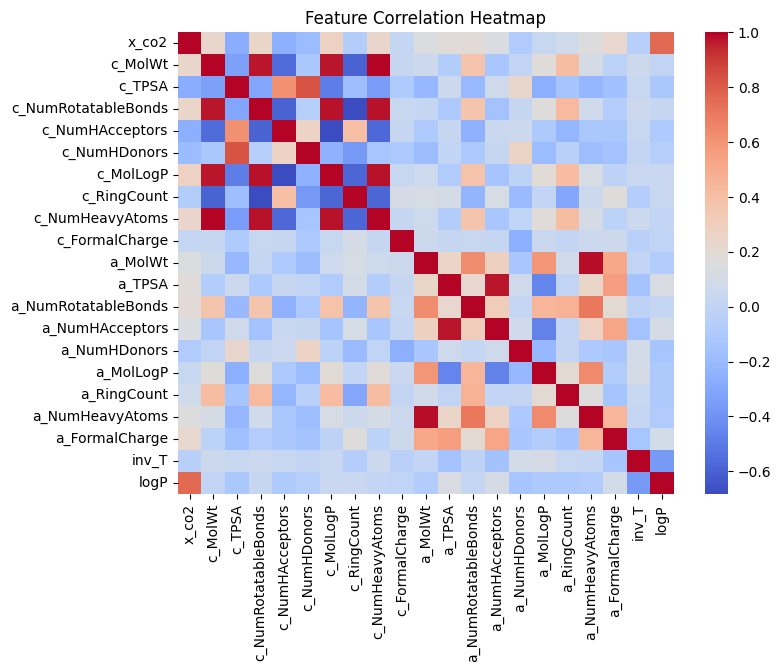

In [1226]:
plt.figure(figsize=(8, 6))
sns.heatmap(train_merged.corr(), cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

In [1227]:
train_merged.head()


,x_co2,c_MolWt,c_TPSA,c_NumRotatableBonds,c_NumHAcceptors,c_NumHDonors,c_MolLogP,c_RingCount,c_NumHeavyAtoms,c_FormalCharge,a_MolWt,a_TPSA,a_NumRotatableBonds,a_NumHAcceptors,a_NumHDonors,a_MolLogP,a_RingCount,a_NumHeavyAtoms,a_FormalCharge,inv_T,logP
0,0.159,140.23,9.14,3.0,2.0,0.0,1.3007,1.0,10.0,1.0,46.074,23.79,0.0,1.0,0.0,0.66328,0.0,2.0,0.0,0.003299,2.079442
1,0.159,140.23,9.14,3.0,2.0,0.0,1.3007,1.0,10.0,1.0,46.074,23.79,0.0,1.0,0.0,0.66328,0.0,2.0,0.0,0.003193,2.370244
2,0.159,140.23,9.14,3.0,2.0,0.0,1.3007,1.0,10.0,1.0,46.074,23.79,0.0,1.0,0.0,0.66328,0.0,2.0,0.0,0.003095,2.610070
3,0.159,140.23,9.14,3.0,2.0,0.0,1.3007,1.0,10.0,1.0,46.074,23.79,0.0,1.0,0.0,0.66328,0.0,2.0,0.0,0.003002,2.856470
4,0.159,140.23,9.14,3.0,2.0,0.0,1.3007,1.0,10.0,1.0,46.074,23.79,0.0,1.0,0.0,0.66328,0.0,2.0,0.0,0.002914,3.100092


In [1228]:
numeric_cols = train_merged.select_dtypes(include=['number'])
correlation_with_target = numeric_cols.corr()['x_co2'].sort_values(key=abs, ascending=False)
print(correlation_with_target)


x_co2                  1.000000
logP                   0.762478
c_MolLogP              0.274753
c_TPSA                -0.272182
c_NumHAcceptors       -0.268257
c_NumRotatableBonds    0.246510
c_NumHeavyAtoms        0.238949
c_MolWt                0.231820
a_FormalCharge         0.224971
c_NumHDonors          -0.193018
a_NumRotatableBonds    0.188585
a_TPSA                 0.181523
a_NumHeavyAtoms        0.162649
a_MolWt                0.151372
a_NumHAcceptors        0.138151
a_NumHDonors          -0.088007
a_RingCount            0.077902
c_RingCount           -0.074925
inv_T                 -0.054211
a_MolLogP              0.028401
c_FormalCharge         0.013980
Name: x_co2, dtype: float64


In [1229]:
corr_matrix = train_merged.corr()
pairwise_corr = (corr_matrix.stack().reset_index().rename(columns={'level_0': 'Feature1', 'level_1': 'Feature2', 0: 'Correlation'}))
pairwise_corr = pairwise_corr[pairwise_corr['Feature1'] != pairwise_corr['Feature2']]
pairwise_corr['Pair'] = pairwise_corr.apply(
    lambda row: tuple(sorted([row['Feature1'], row['Feature2']])), axis=1)
pairwise_corr = pairwise_corr.drop_duplicates('Pair').drop(columns='Pair')
pairwise_corr['AbsCorr'] = pairwise_corr['Correlation'].abs()
pairwise_corr = pairwise_corr.sort_values(by='AbsCorr', ascending=False).reset_index(drop=True)
print(pairwise_corr.head(10))


              Feature1             Feature2  Correlation   AbsCorr
0              c_MolWt      c_NumHeavyAtoms     0.998855  0.998855
1              a_MolWt      a_NumHeavyAtoms     0.985651  0.985651
2            c_MolLogP      c_NumHeavyAtoms     0.977992  0.977992
3  c_NumRotatableBonds      c_NumHeavyAtoms     0.975041  0.975041
4  c_NumRotatableBonds            c_MolLogP     0.973983  0.973983
5              c_MolWt            c_MolLogP     0.972793  0.972793
6              c_MolWt  c_NumRotatableBonds     0.970406  0.970406
7               a_TPSA      a_NumHAcceptors     0.967283  0.967283
8               c_TPSA         c_NumHDonors     0.826476  0.826476
9                x_co2                 logP     0.762478  0.762478


In [1230]:
columns_to_drop = ['c_MolWt','c_NumRotatableBonds','c_NumHeavyAtoms','a_MolWt']
train_merged = train_merged.drop(columns=columns_to_drop)
test_merged = test_merged.drop(columns=columns_to_drop)


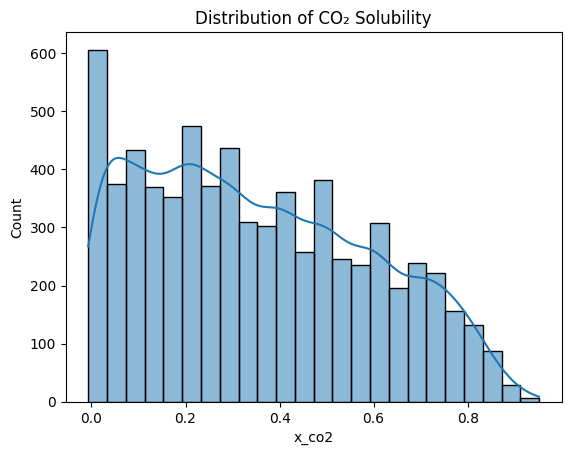

In [1231]:
sns.histplot(train_merged['x_co2'], kde=True)
plt.title("Distribution of CO₂ Solubility")
plt.show()


In [1232]:
skewed_feats = train_merged.drop(columns=['x_co2']).skew().sort_values(ascending=False)
print("Top 10 most skewed features:\n")
print(skewed_feats.head(10))

Top 10 most skewed features:

a_NumHDonors           6.465151
a_RingCount            5.675947
c_NumHDonors           4.987401
a_NumRotatableBonds    2.829399
c_TPSA                 2.799256
c_MolLogP              2.283961
a_MolLogP              1.682357
a_NumHeavyAtoms        0.532823
a_FormalCharge         0.328673
logP                  -0.146939
dtype: float64


In [1233]:
train_merged.head()

,x_co2,c_TPSA,c_NumHAcceptors,c_NumHDonors,c_MolLogP,c_RingCount,c_FormalCharge,a_TPSA,a_NumRotatableBonds,a_NumHAcceptors,a_NumHDonors,a_MolLogP,a_RingCount,a_NumHeavyAtoms,a_FormalCharge,inv_T,logP
0,0.159,9.14,2.0,0.0,1.3007,1.0,1.0,23.79,0.0,1.0,0.0,0.66328,0.0,2.0,0.0,0.003299,2.079442
1,0.159,9.14,2.0,0.0,1.3007,1.0,1.0,23.79,0.0,1.0,0.0,0.66328,0.0,2.0,0.0,0.003193,2.370244
2,0.159,9.14,2.0,0.0,1.3007,1.0,1.0,23.79,0.0,1.0,0.0,0.66328,0.0,2.0,0.0,0.003095,2.610070
3,0.159,9.14,2.0,0.0,1.3007,1.0,1.0,23.79,0.0,1.0,0.0,0.66328,0.0,2.0,0.0,0.003002,2.856470
4,0.159,9.14,2.0,0.0,1.3007,1.0,1.0,23.79,0.0,1.0,0.0,0.66328,0.0,2.0,0.0,0.002914,3.100092


In [1234]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [1235]:
# 2. Prepare features and target
X = train_merged.drop(columns=['x_co2'])
y = train_merged['x_co2']
# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# 4. Define models in a dictionary
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting (GBR)': GradientBoostingRegressor(random_state=42),
    'XGBoost (XGBR)':XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, reg_alpha=0.1, reg_lambda=1),
    'LightGBM (LGBMR)': LGBMRegressor(n_estimators=100, random_state=42),
    'Support Vector (SVR)': SVR(),
    'Decision Tree': DecisionTreeRegressor(random_state=42)
}
# 5. Loop through each model and evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    r2_train = r2_score(y_train, model.predict(X_train))
    rmse = mean_squared_error(y_test, y_pred)
    print(f' {name}')
    print(f'   R² Score: {r2}')
    print(f' R² Score (Train): {r2_train}')
    print(f'   RMSE: {rmse}')
    print('-' * 50)

 Linear Regression
   R² Score: 0.7748223696839034
 R² Score (Train): 0.783903277764772
   RMSE: 0.013074226654769787
--------------------------------------------------
 Random Forest
   R² Score: 0.9733202592990438
 R² Score (Train): 0.9968946082139156
   RMSE: 0.0015490747305810556
--------------------------------------------------
 Gradient Boosting (GBR)
   R² Score: 0.947682309252454
 R² Score (Train): 0.9567877671262819
   RMSE: 0.003037661182984179
--------------------------------------------------
 XGBoost (XGBR)
   R² Score: 0.9631906972830587
 R² Score (Train): 0.9752699709419113
   RMSE: 0.0021372156996667794
--------------------------------------------------
 LightGBM (LGBMR)
   R² Score: 0.9776314714165077
 R² Score (Train): 0.9888482019556194
   RMSE: 0.0012987578394165575
--------------------------------------------------
 Support Vector (SVR)
   R² Score: 0.7546145751631924
 R² Score (Train): 0.7705057474090409
   RMSE: 0.014247528307273697
-----------------------------

In [1236]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# 1. Prepare features and target
X = train_merged.drop(columns=['x_co2'])
y = train_merged['x_co2']

# 2. Define models for ensembling
models = {
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, reg_alpha=0.1, reg_lambda=1),
    'LightGBM': LGBMRegressor(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(random_state=42),
    'DecisionTree': DecisionTreeRegressor(random_state=42)
}

# 3. Dictionary to store predictions
test_preds = []

# 4. Train each model, evaluate, and predict
for name, model in models.items():
    print(f'Training: {name}')

    # Cross-validation
    r2_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    print(f'   Avg R² Score: {r2_scores.mean():.4f}')

    # Train on full data
    model.fit(X, y)

    # Predict on test data
    preds = model.predict(test_merged.drop(columns=['Id']))
    test_preds.append(preds)

# 5. Average predictions across all models
ensemble_preds = np.mean(test_preds, axis=0)
submission = pd.DataFrame({
    'Id': test_merged['Id'],  # ← Change 'molecule_id' to your actual column name
    'Predicted_x_co2': ensemble_preds
})
submission.to_csv('ensemble_average_submission.csv', index=False)
print("Ensemble predictions saved as 'ensemble_average_submission.csv'")
from google.colab import files
files.download('ensemble_average_submission.csv')

Training: RandomForest
   Avg R² Score: 0.7945
Training: XGBoost
   Avg R² Score: 0.8124
Training: LightGBM
   Avg R² Score: 0.8026
Training: GradientBoosting
   Avg R² Score: 0.7906
Training: DecisionTree
   Avg R² Score: 0.6925
Ensemble predictions saved as 'ensemble_average_submission.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>